Name: Elsa Ingrid Daniela Erkfeldt
Civic number: 200309021228
LMM use:

In [4]:
!pip install -q transformers[sentencepiece] accelerate

!pip install peft


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from peft import LoraConfig, get_peft_model

from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")


from sklearn.datasets import make_classification


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

import random



c:\Users\erkfeldt\AppData\Local\miniconda3\envs\pytorch-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

In [6]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [7]:

import torch
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print("gpu name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

cuda available: True
device count: 1
gpu name: NVIDIA GeForce RTX 3070


Assignment 3
Compare BERT to interpretable classifiers for text classification

1. Download the ReviewBase data set.    
Split data on space character.   
The data set also contains a class labels associated with each text





In [8]:
#Get data for review base
file_training = open('ReviewBaseTraining.txt', 'r', encoding = 'utf-8')
training_data_string = file_training.read()
file_training.close()

file_validation = open('ReviewBaseValidation.txt', 'r', encoding = 'utf-8')
validation_data_string = file_validation.read()
file_validation.close()

file_test = open('ReviewBaseTest.txt', 'r', encoding = 'utf-8')
test_data_string = file_test.read()
file_test.close()


In [9]:
#Split into lines
training_data = training_data_string.splitlines()
validation_data = validation_data_string.splitlines()
test_data = test_data_string.splitlines()



#Split into labels and text
def split_labels(data):
    current_label = None
    x = []
    y = []
    for word in data:
        label, text = word.split("\t")
        x.append(text)
        y.append(label)
    return x, y

x_train, y_train = split_labels(training_data)
x_val, y_val = split_labels(validation_data)
x_test, y_test = split_labels(test_data)

#Make labels integers
y_train = [int(label) for label in y_train]
y_val = [int(label) for label in y_val]
y_test = [int(label) for label in y_test]




Set up and fine-tune the DeBERTa-v3 model using low-rank adaptiation(LoRA)
Use a single fully connected layer (after transformer bloacks)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#CHoose model
model_name = "microsoft/deberta-v3-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

train_data = [(x, y) for x, y in zip(x_train, y_train)]
test_data = [(x, y) for x, y in zip(x_test, y_test)]
validation_data = [(x, y) for x, y in zip(x_val, y_val)]

dataloaded_train = DataLoader(train_data, batch_size = 32, shuffle = True)
data_loader_test = DataLoader(test_data, batch_size = 32, shuffle = False)
data_loader_val = DataLoader(validation_data, batch_size = 32, shuffle = False)



#Use low rank adaption for fine tuning
lora_config = LoraConfig(r = 8, target_modules = ["query_proj", "key_proj", "value_proj"])

model = get_peft_model(model, lora_config)
model.to(device)

trainable = 0
total = 0
for p in model.parameters():
  total += p.numel()
  if p.requires_grad:
    trainable += p.numel()

    
print(f"Trainable params: {trainable:,}")
print(f"Total params {total:,}")
print(f"Trainable: {100*trainable/total:.4f}%")




Loading weights: 100%|██████████| 102/102 [00:00<00:00, 50997.62it/s]
DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.den

Trainable params: 221,184
Total params 142,117,634
Trainable: 0.1556%


In [39]:

optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=1e-4)

epochs = 5

#A single fully connected layer was used to train
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    steps = 0
    for batch in dataloaded_train:
        texts, labels = batch

        train_x_token = tokenizer(list(texts), return_tensors="pt", truncation = True, padding = True, max_length = 128).to(device)

        labels_t = labels.to(device)
        #optimizer = "hddell"
        #Actual training
        out = model(input_ids = train_x_token["input_ids"], labels = labels_t, attention_mask = train_x_token["attention_mask"])
        loss = out.loss


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        steps += 1
    
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for batch in data_loader_val:
            texts, labels = batch
            
            val_x_tokens = tokenizer(list(texts), return_tensors="pt", truncation = True, padding = True, max_length = 128).to(device)
            labels_t = labels.to(device)
            
            outputs = model(input_ids = val_x_tokens["input_ids"], attention_mask = val_x_tokens["attention_mask"])
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            preds.extend(predictions.cpu().numpy())
            actuals.extend(labels_t.cpu().numpy())



    print(f"epoch {epoch+1}, avg_loss = {running_loss/steps}")
    accuracy = accuracy_score(actuals, preds)
    print(f"val_accuracy: {accuracy:.4f}")


epoch 1, avg_loss = 0.28586353711522045
val_accuracy: 0.8784
epoch 2, avg_loss = 0.27408826103606543
val_accuracy: 0.8806
epoch 3, avg_loss = 0.2611497837228897
val_accuracy: 0.8782
epoch 4, avg_loss = 0.2515500349144395
val_accuracy: 0.8828
epoch 5, avg_loss = 0.24138806831722442
val_accuracy: 0.8848


In [ ]:
#DOublechecking?
print(model)

Set up and train a linear perceptron using n-gram for the same task

Run for n_max = 1 (unigrams onlt), n_max =2 (unigrams and bigrams) and n_max = 3 (unigrams, bigrams and trigrams).

for each n, try different minimum instance counts (cmin) for feature inclusion (1,2,10,100)
Then extract the model with highest validation accuracy (for each n) and compute its accuracy over the test set

In [32]:
thresh = 0
n_features = 2
c_min = 3

#Function to classify one review
def classify(weights, x, bias, threshold):
  y = x.dot(weights).item() + bias
  if y>=threshold:
    return 1
  else:
    return 0

#Function to calcualte the accuracy
def accuracy_calc(weights, vectorized_val, bias, labels, threshold = thresh):
  scores = vectorized_val @ weights + bias
  preds = (scores >= threshold).astype(int)
  labels = np.asarray(labels, dtype=int)
  accuracy = (preds == labels).mean()
  return accuracy


#Setting up and training hte linear perceptron
def linear_perceptron(n, texts, c_min, labels, eta, epochs, threshold = thresh):
  vectorizer = CountVectorizer(ngram_range=(1, n), min_df = c_min)
  vectorized = vectorizer.fit_transform(texts)
  weights = np.zeros(vectorized.shape[1])
  bias = 0.0

  for epoch in range(epochs):

    order = np.random.permutation(len(texts))

    for i in order:
      #x_i = vectorized[i].toarray().ravel().astype(float)
      #x_dense = x_i.toarray().ravel()
      score = vectorized[i].dot(weights) + bias
      if score >= threshold:
        predicted = 1
      else:
        predicted = 0
      if predicted != labels[i]:
        row = vectorized[i]
        indices = row.indices
        values = row.data
        dif_eta = eta*(labels[i] - predicted)
        weights[indices] +=dif_eta * values
        bias += dif_eta

  return weights, vectorizer, bias


eta = 0.01
epochs = 50
labels = y_train

c_mins = [1, 3, 10, 100]

y_val = [int(l) for l in y_val]
weights_list = []
biases_list = []
vectoriser_list = []

#Go through the different n_max and find the max accuracy by comparing different c_min
for n in range(1, 4):
  best_accuracy = -1
  best_c_min = None
  best_weights = None
  best_vectorizer = None
  best_bias = None


  for i, c_min in enumerate(c_mins):
    weights, vectorizer, bias = linear_perceptron(n, x_train, c_min, y_train, eta, epochs)
    vectorized_val = vectorizer.transform(x_val)

    accuracy = accuracy_calc(weights, vectorized_val, bias, y_val)
    if accuracy >= best_accuracy:
      best_accuracy = accuracy
      best_c_min = c_min
      best_weights = weights
      best_vectorizer = vectorizer
      best_vectorizer_val = vectorized_val
      best_bias = bias


  weights_list.append(best_weights)
  biases_list.append(best_bias)
  vectoriser_list.append(best_vectorizer)
  

  print(f"for n = {n}, the best c_min is {best_c_min} with accuracy {best_accuracy}")

  vectorised_test_val = best_vectorizer.transform(x_test)
  test_accuracy = accuracy_calc(best_weights, vectorised_test_val, best_bias, y_test)
  
  print(f"test accuracy: {test_accuracy}")




for n = 1, the best c_min is 3 with accuracy 0.8318
test accuracy: 0.849
for n = 2, the best c_min is 3 with accuracy 0.8542
test accuracy: 0.8756
for n = 3, the best c_min is 1 with accuracy 0.8608
test accuracy: 0.8764


Plot (diagram) showing all the unigrams, bigrams and trigrams, with a green bar for positive weights and red bar for negative weights.
Length of bar propotional to weight magnitude
Apply this visualizer to a few shorter reviews

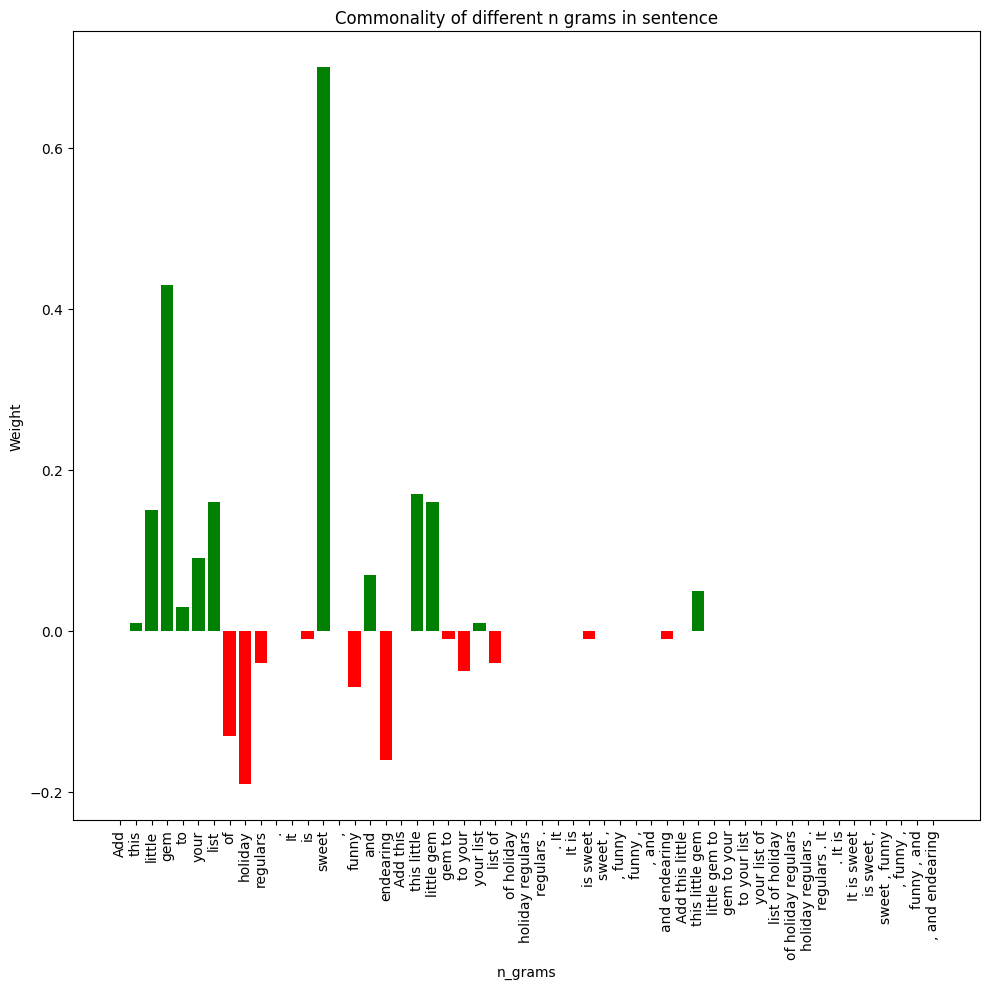

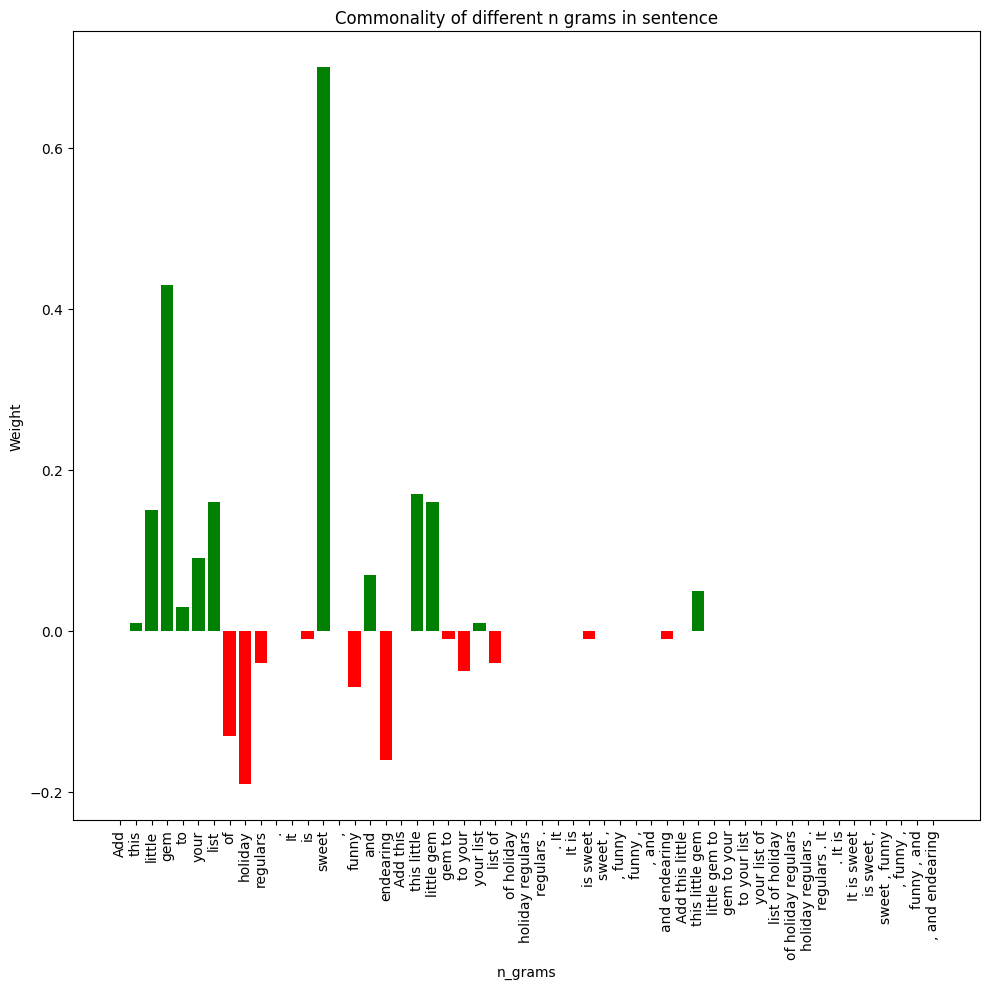

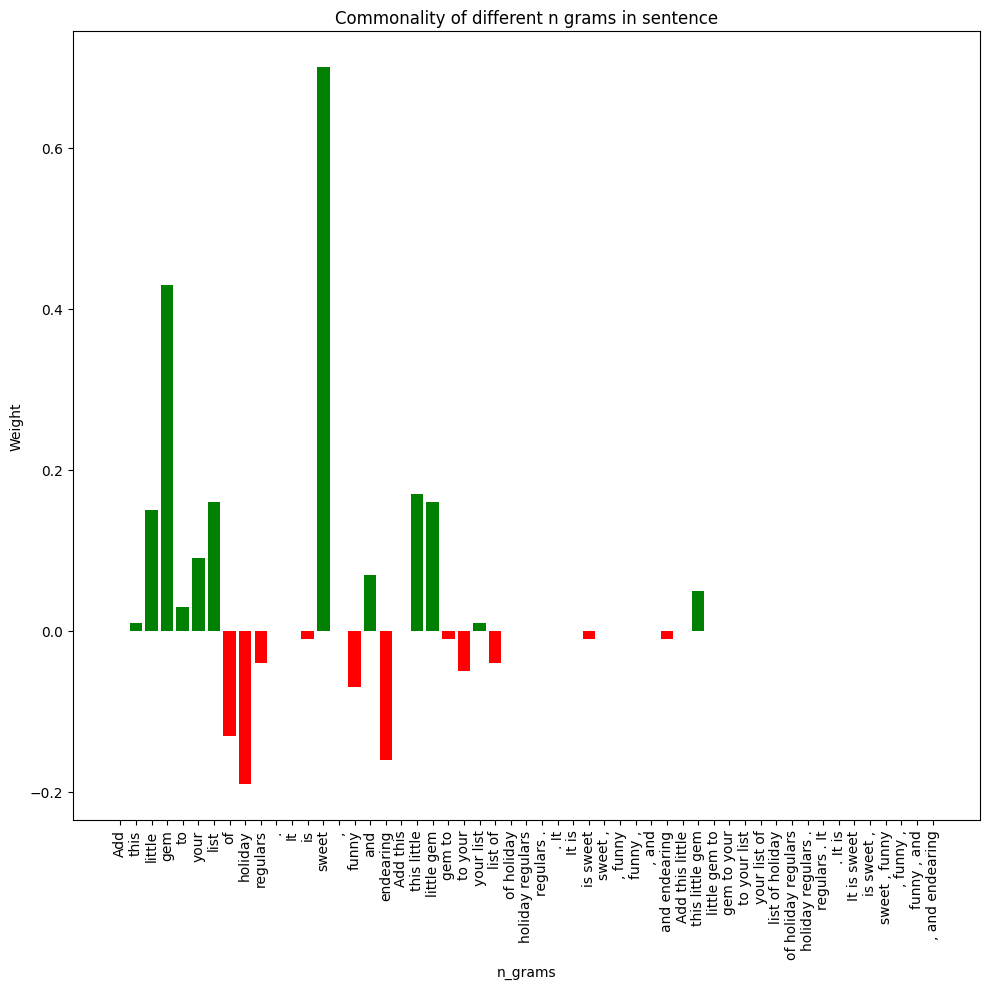

In [33]:
def plot( weights, vect, words):
  unigram_weight = weights[0]
  bigram_weight = weights[1]
  trigram_weight = weights[2]
  uni_grams = words.copy()
  bi_grams = []
  for i in range(len(words) -1):
    bi_grams.append(words[i] + " " + words[i+1])
  tr_grams = []
  for i in range(len(words) -2):
    tr_grams.append(words[i] + " " + words[i+1] + " " + words[i+2])
  unigram_in_voc = vect[0].vocabulary_
  bigrams_in_voc = vect[1].vocabulary_
  trigrams_in_voc = vect[2].vocabulary_
  indexes = []
  plot_words = []
  colours = []
  weights_used = []

  for gram in uni_grams + bi_grams + tr_grams:
    if gram in unigram_in_voc:
      idx = unigram_in_voc[gram]
      weight = unigram_weight[idx]
    elif gram in bigrams_in_voc:
      idx = bigrams_in_voc[gram]
      weight = bigram_weight[idx]
    elif gram in trigrams_in_voc:
      idx = trigrams_in_voc[gram]
      weight = trigram_weight[idx]
    else:
      weight = 0.0

    plot_words.append(gram)
    weights_used.append(weight)
    if weight > 0:
      colours.append("green")
    elif weight == 0:
      colours.append("gray")
    else:
      colours.append("red")

  plt.figure(figsize=[10,10])
  plt.bar(plot_words, weights_used, color = colours)
  plt.title("Commonality of different n grams in sentence")
  plt.xlabel("n_grams")
  plt.ylabel("Weight")
  plt.xticks(rotation=90)
  plt.tight_layout()

  plt.show()

num_graphs = 3

for _ in range(num_graphs):
  short_sentence = False
  while not short_sentence:
    rnd = random.randint(0, len(x_test)-1)
    words = x_test[rnd].split()
    if 15 <= len(words)<= 25:
      short_sentence = True
      sentence_num = rnd
      sentence = x_test[sentence_num]

  plot(weights_list, vectoriser_list, words)






Coverage ratio was then calcualted. Coverage ratio is the restio between the num of ngrams that exist in the vocubalary and those that do not.

In [35]:


found_1 = 0
total_1 = 0
found_2 = 0
total_2 = 0
found_3 = 0
total_3 = 0
unigram_voc = vectoriser_list[0].vocabulary_
bigram_voc = vectoriser_list[1].vocabulary_
trigram_voc = vectoriser_list[2].vocabulary_
for i, sentences in enumerate(x_test):
  n_grams = sentences.split()
  list_2s = []
  for i in range(len(n_grams)-1):
    list_2s.append(n_grams[i] + " " + n_grams[i+1])
  list_3s = []
  for i in range(len(n_grams)-2):
    list_3s.append(n_grams[i] + " " + n_grams[i+1] + " " + n_grams[i+2])
  
  for gram in n_grams:
    if gram in unigram_voc:
      found_1 += 1
    total_1 += 1

  for gram in list_2s:
    if gram in bigram_voc:
      found_2 += 1
    total_2 += 1

  for gram in list_3s:
    if gram in trigram_voc:
      found_3 += 1
    total_3 += 1

print(f"found {found_1} out of {total_1} unigrams in the test set")
coverage_ratio_1 = found_1 / total_1
print(f"coverage ratio: {coverage_ratio_1:.4f}")

print(f"found {found_2} out of {total_2} bigrams in the test set")
coverage_ratio_2 = found_2 / total_2
print(f"coverage ratio: {coverage_ratio_2:.4f}")

print(f"found {found_3} out of {total_3} trigrams in the test set")
coverage_ratio_3 = found_3 / total_3
print(f"coverage ratio: {coverage_ratio_3:.4f}")



found 921465 out of 1331661 unigrams in the test set
coverage ratio: 0.6920
found 525362 out of 1326661 bigrams in the test set
coverage ratio: 0.3960
found 253059 out of 1321661 trigrams in the test set
coverage ratio: 0.1915


Review Extended consists of a training and a validation set.
Train linear perceptron model with n_max = 1, n_max = 2, n_max = 3
Find higherst accuracy
For each n, average the weights from the orginal base model with the weights obtained for the extended model as w_c = alpha * w_b + (1 - alpha) * w_e
w_b: weight from base
w_e: weight from extended
(if w_b does not exist, w_c = w_e)
Chose the alpha for each n that maximises accuracy over validation set from base

In [36]:
#Import extended dataset
file_training_extended = open('ReviewExtendedTraining.txt', 'r', encoding = 'utf-8')
training_data_string_extended = file_training_extended.read()
file_training_extended.close()



file_validation_extended = open('ReviewExtendedValidation.txt', 'r', encoding = 'utf-8')
validation_data_string_extended = file_validation_extended.read()
file_validation_extended.close()

training_data_extended = training_data_string_extended.splitlines()
validation_data_extended = validation_data_string_extended.splitlines()

#Split into labels and text
def split_labels_ext(data):
    current_label = None
    x = []
    y = []
    for i, word in enumerate(data):
      if "\t" in word:
        label, text = word.split("\t", 1)
      else:
        label, text = word.split(None, 1)
      if label== "0" or label == "1":
        x.append(text)
        y.append(int(label))
    return x, y

x_train_ex, y_train_extended = split_labels_ext(training_data_extended)
x_val_ex, y_val_extended = split_labels_ext(validation_data_extended)

#Make labels into integers
y_train_ex = [int(label) for label in y_train_extended]
y_val_ex = [int(label) for label in y_val_extended]


Find the c_min with the highest accuracy for this new extende model for each n_max.


In [37]:
c_mins = [1, 3, 10, 100]
ex_weights = []
ex_biases = []
chosen_c_mins = []
ex_vectoriser = []

In [ ]:
n = 1
best_accuracy_ex = -1
best_c_min_ex = None
best_weights_ex = None
best_vectorizer_ex = None
best_bias_ex = None
best_i = None

for i, c_min in enumerate(c_mins):
  weights, vectorizer, bias = linear_perceptron(n, x_train_ex, c_min, y_train_ex, eta, epochs)
  vectorized_val = vectorizer.transform(x_val_ex)
  accuracy = accuracy_calc(weights, vectorized_val, bias, y_val_ex)

  if accuracy >= best_accuracy_ex:
    best_accuracy_ex = accuracy
    best_c_min_ex = c_min
    best_weights_ex = weights
    best_vectorizer_ex = vectorizer
    best_vectorizer_val_ex = vectorized_val
    best_bias_ex = bias
    best_i = i

ex_weights.append(best_weights_ex)
ex_biases.append(best_bias_ex)
chosen_c_mins.append(best_i)
ex_vectoriser.append(best_vectorizer_ex)


print(f"for n = {n}, the best c_min is {best_c_min_ex} with accuracy {best_accuracy_ex}")


In [ ]:
n = 2
best_accuracy_ex = -1
best_c_min_ex = None
best_weights_ex = None
best_vectorizer_ex = None
best_bias_ex = None
best_i = None

for i, c_min in enumerate(c_mins):
  weights, vectorizer, bias = linear_perceptron(n, x_train_ex, c_min, y_train_ex, eta, epochs)
  vectorized_val = vectorizer.transform(x_val_ex)
  accuracy = accuracy_calc(weights, vectorized_val, bias, y_val_ex)

  if accuracy >= best_accuracy_ex:
    best_accuracy_ex = accuracy
    best_c_min_ex = c_min
    best_weights_ex = weights
    best_vectorizer_ex = vectorizer
    best_vectorizer_val_ex = vectorized_val
    best_bias_ex = bias
    best_i = i

ex_weights.append(best_weights_ex)
ex_biases.append(best_bias_ex)
chosen_c_mins.append(best_i)
ex_vectoriser.append(best_vectorizer_ex)


print(f"for n = {n}, the best c_min is {best_c_min_ex} with accuracy {best_accuracy_ex}")


0
10
20
30
40
0
10
20
30
40
0
10


KeyboardInterrupt: 

In [ ]:
n = 3
best_accuracy_ex = -1
best_c_min_ex = None
best_weights_ex = None
best_vectorizer_ex = None
best_bias_ex = None
best_i = None

for i, c_min in enumerate(c_mins):
  weights, vectorizer, bias = linear_perceptron(n, x_train_ex, c_min, y_train_ex, eta, epochs)
  vectorized_val = vectorizer.transform(x_val_ex)
  accuracy = accuracy_calc(weights, vectorized_val, bias, y_val_ex)

  if accuracy >= best_accuracy_ex:
    best_accuracy_ex = accuracy
    best_c_min_ex = c_min
    best_weights_ex = weights
    best_vectorizer_ex = vectorizer
    best_vectorizer_val_ex = vectorized_val
    best_bias_ex = bias
    best_i = i

ex_weights.append(best_weights_ex)
ex_biases.append(best_bias_ex)
chosen_c_mins.append(best_i)
ex_vectoriser.append(best_vectorizer_ex)


print(f"for n = {n}, the best c_min is {best_c_min_ex} with accuracy {best_accuracy_ex}")


0
10
20
30
40
0
10
20
30
40
0
10
20
30
40
0
10
20
30
40
for n = 3, the best c_min is 1 with accuracy 0.88536


For each n, average the weights from the original base model with the weights obtianed for the extended model as w_c = alpha * w_b + (1 - alpha) * w_e.
Chose the alpha for each n that maximises accuracy over validation set from base



In [ ]:

alphas = [0.01, 0.05, 0.1, 0.5]

unigram_words = ex_vectorizer[0].get_feature_names_out()
bigram_words = ex_vectorizer[1].get_feature_names_out()
trigram_words = ex_vectorizer[2].get_feature_names_out()

n_to_w_ex = {word: ex_weights[0][i] for i, word in enumerate(unigram_words)}
n_to_w_ex = {word: ex_weights[1][i] for i, word in enumerate(bigram_words)}
n_to_w_ex = {word: ex_weights[2][i] for i, word in enumerate(trigram_words)}
n_to_w = {word: weights_list[0][i] for i, word in enumerate(unigram_words[0].get_feature_names_out())}
n_to_w = {word: weights_list[1][i] for i, word in enumerate(bigram_words[1].get_feature_names_out())}
n_to_w = {word: weights_list[2][i] for i, word in enumerate(trigram_words[2].get_feature_names_out())}


unigrams_base = best_vectorizer[0].get_feature_names_out()
bigram_base = best_vectorizer[1].get_feature_names_out()
trigram_base = best_vectorizer[2].get_feature_names_out()

all_unigrams = list(set(unigrams_base) | set(unigram_words))
all_bigrams = list(set(bigram_base) | set(bigram_words))
all_trigrams = list(set(trigram_base) | set(trigram_words))



for alpha in alphas:
  full_dictionary = {}
  for word in all_unigrams + all_bigrams + all_trigrams:
    w_e = n_to_w_ex.get(word, None)
    w_b = n_to_w.get(word, None)

    if w_e == None:
      w_c = w_b
    elif w_b == None:
      w_c = w_e
    else:
      w_c = alpha*w_b + (1-alpha)* w_e

    full_dictionary[word] = w_c
  
  full_list = list(full_dictionary.keys()) #Isnt this just all_words?
  weights_for_final = np.array([full_dictionary[word] for word in full_list])

  b_c = alpha * best_bias + (1-alpha) * best_bias_ex
  accuracy = accuracy_calc(weights_for_final, vectorized_val, b_c, y_val)
  print(f"For alpha {alpha}, accuracy is {accuracy}")







NameError: name 'ex_weights' is not defined

Table for the final test accuracy:

In [ ]:
import pandas as pd

data = {
    "Model": [
        "DeBERTa-v3",
        "Perceptron n=1",
        "Perceptron n=2",
        "Perceptron n=3",
        "Extended perceptron n=1",
        "Extended perceptron n=2",
        "Extended perceptron n=3"
    ],
    "Accuracy": [
        88.5%,
        84.9%,
        87.6%,
        87.6%,
        ext1_acc,
        ext2_acc,
        ext3_acc
    ]
}

table = pd.DataFrame(data)

print(table)